# Tutorial 2: Bayesian inference and Quantum non Demolition (QND) Photon Counting

Serge Haroche shared the 2012 Nobel Prize in Physics for experimental methods that enable the measurement and manipulation of individual quantum systems.  In the experiment studied here, a high-quality microwave cavity stores a very small field, and successive Rydberg atoms probe its photon number without appreciably absorbing the photons.

We will reanalyse data from Guerlin *et al.* [[1]](https://arxiv.org/abs/0707.3880), kindly provided by Igor Dotsenko (see also the notes of the lectures given in 2008 at the
College de France [ [2](https://www.college-de-france.fr/sites/default/files/documents/serge-haroche/UPL50478_SHaroche_03032008_6.pdf) ]). The goal of this tutorial is to infer the unknown photon number from noisy atomic measurements using Bayes' rule.

![QND](QND.png)

## Physical picture and notation

The two states denoted by $g$ and $e$ are two circular Rydberg levels of the atom. They form an effective two-level system, or **pseudospin**.
Each photon the atom encounters produces a phase-shift $\Phi$ (see Fig 1), measured by a Ramsey interferometer.
Trajectories of repeated detections of the
pseudospin states of the atoms passing in the cavity will be used to infer the number of photons in the field.
During the evolution of the measures we will observe the creation or the destructions of photons in
the cavity up to the collapse in a Fock state.
The probability to detect the spin in the ground state or in the excited state depends on the number of
photons $n$ in the cavity. For the calibrated interferometer these probabilities are modeled as

$$ P(g|\phi_k,n)=A-\frac{B}{2} \cos(n\Phi+\phi_k)\\ P(e|\phi_k,n)=1-A+\frac{B}{2} \cos(n\Phi+\phi_k)$$

where the parameters $A = 0.551$ (offset) and $B = 0.698$ (contrast) depends on the interferometer; the
phase $\Phi = 0.233 \pi (\approx \pi /4)$ is fixed to detect a number of photons in the cavity ranging from 0 to 7, and the
initial state of the atom is prepared with four initial phases $\phi_k = −0.836, 0.033, 0.905, 1.442$ , calibrated for
optimal detections, such phases are changed cyclically during the experiments.


**Data**: `stateG.dat` and `stateE.dat` contain arrays $G$ and $E$ of shape $N_{\rm exp}\times T$. Each row is one independent experimental realization. The entry $G_{r,t}$ (respectively $E_{r,t}$) is the number of atoms detected in $g$ (respectively $e$) during time bin $t$, with Ramsey phase $\phi_{k(t)}$. The four possible Ramsey phases are cyclically changed to $\phi_0,\;\phi_1,\;\phi_2,;\phi_3,\;\phi_0,...$ along each quantum trajectory (in other words, $k(t)=t_{\mod 4}$).

Assumptions: In the cavity, each atom is independent from the others.


In [3]:
import numpy as np
import math
import matplotlib.pyplot as plt
import numpy.matlib
import csv
import pandas as pd
from scipy import stats
import math

# Set global font sizes for labels and ticks
plt.rcParams['axes.labelsize'] = 20    # axis labels (xlabel, ylabel)
plt.rcParams['xtick.labelsize'] = 16   # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 16   # y-axis tick labels

### 0) Read the data

In [4]:
#2 files containing  atomic detections in  ground state 'stateG.dat' or excited state 'stateE.dat'


# they are a matrix Nexp x T where Nex=2000 is the number of independent experiments
#each  of such trajectory  (rows of the matrix) having  T=10000 detections d,  d=0,1,2,3.. 
#indicating the number of atoms detected in the corresponding g,e state.



T=10000
Nexp=2000

#Open and read the files:

f0=open("stateG.dat")

l=0

G=np.zeros((Nexp,T)).astype(int)
for row in csv.reader(f0):
    G[l,:]=row
    l=l+1
    
f1=open("stateE.dat")

l=0
E=np.zeros((Nexp,T)).astype(int)
for row in csv.reader(f1):
    E[l,:]=row
    l=l+1
    

In [5]:
G.shape

(2000, 10000)

### Question 1(a) — Likelihood and posterior
Write the likelihood of a set of $T$ detections along a quantum trajectory, given a number $n$ of
photons in the cavity and the protocol of Ramsey phases $k(t)$ used in the experiment. Deduce, using
Bayes rule, the probability of the number $n$ of photons in the cavity given the detections along a
quantum trajectory. Use an uniform prior in the interval $n = 0, . . ., 7 $. What is the most likely photon count in the first experiment?

#### Answer:

A trajectory corresponds to the $T$ detections of the number of excited and ground state photons. For a given experiment number $r$, the likelihood of data knowing that there are $n$ photons in the cavity and knowing the Ramsey phase cycle $k(t)$ is given by

$$ \mathbb{P}((E_{r,t},G_{r,t})_{t=0,\ldots, T-1}|n,(k(t))_{t=0,\ldots, T-1})=\prod_{t=0}^{T-1} \binom{G_{r,t}+E_{r,t}}{G_{r,t}}  P(e|n,\phi_{k(t)})^{E_{r,t}}  P(g|n,\phi_{k(t)})^{G_{r,t}} $$

By assuming uniform prior, we have (for $0\leq n \leq 7$)
$$ \mathbb{P}(n|(E_{r,t},G_{r,t})_{t=0,\ldots, T-1},(k(t))_{t=0,\ldots, T-1})= \frac{ \mathbb{P}((E_{r,t},G_{r,t})_{t=0,\ldots, T-1}|n,(k(t))_{t=0,\ldots, T-1})}{\sum_{m=0}^7 \mathbb{P}((E_{r,t},G_{r,t})_{t=0,\ldots, T-1}|n,(k(t))_{t=0,\ldots, T-1}) } $$
and because we are only interested in the $n$ dependency of the likelihood, 
$$\mathbb{P}(n|(E_{r,t},G_{r,t})_{t=0,\ldots, T-1},(k(t))_{t=0,\ldots, T-1})\propto \prod_{t=0}^{T-1}  P(e|n,\phi_{k(t)})^{E_{r,t}}P(g|n,\phi_{k(t)})^{G_{r,t}} $$
and finally we will maximize the log-likelihood (**forgetting the constant terms independent of $n$**)
$$\mathcal{L}(n|(E_{r,t},G_{r,t})_{t=0,\ldots, T-1},(k(t))_{t=0,\ldots, T-1})= \sum_{t=0}^{T-1} E_{r,t} \log P(e|n,\phi_{k(t)})+ G_{r,t} \log P(g|n,\phi_{k(t)}) $$

In [40]:
def log_likelihood(exp):
    counts_g=G[exp]
    counts_e=E[exp]
    L=np.zeros(8)
    A = 0.551
    B = 0.698
    Φ = 0.233*np.pi
    lphi=[-0.836, 0.033, 0.905, 1.442]
    
    for n in range(8):
        for t in range(len(counts_g)):
            L[n]+=counts_g[t]*np.log(A-B/2*np.cos(n*Φ+lphi[t%4]))+counts_e[t]*np.log(1-A+B/2*np.cos(n*Φ+lphi[t%4]))
    return L


The most likely number of photon is 0


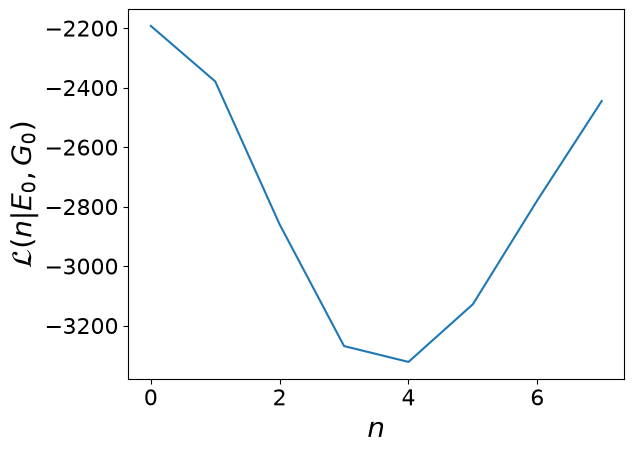

In [41]:
L=log_likelihood(900)
plt.plot(L)
plt.xlabel(r'$n$')
plt.ylabel(r'$\mathcal{L}(n|E_0,G_0)$')
print(f'The most likely number of photon is {np.argmax(L)}')

### Question 1(b) — Grouping observations by Ramsey phase
Re-express the log-probability of the number $n$ of photons in the cavity, using the counts $c^g_k$ for
detections in the state $g$ and $c_k^e$ in the state $e$ for each Ramsey phases ($k = 0, \ldots,  3$). Check that you find the same likelihoods as in Question 1. (a) for the first experiment. 

### Question 2 — Count atoms in a selected window

Focus on the trajectory $r = 1163$ and  the detection interval starting in $t_i = 400$ and ending in
$t_f = t_{i} + M$ with $M = 400$. Count the number of atoms detected during this interval in the state $e$ and $g$ for each Ramsey phases.

**Hint:** Make a function that takes as input the experiment number, the initial time and the final time and outputs the likelihood of each photon number, and the counts of $e$ and $g$ for each Ramsay phase.

### Question 3 - Effects of adding data
Focus on the trajectory $r = 1163$. Plot the probability of $n$ after $M$ detections starting from $t_{i}= 400$
and for $M = 0, 12, 100, 200, 400$. Describe how the posterior evolves as a function of the number of
measures $M$. Compare qualitatively to Fig. 2 of [1].

### Question 4.

Compute the entropy of the posterior after $M$ detections (for $r = 1163$ and $t_{i}= 400$). What is its expected value with no measurement ($M = 0$)? Plots it as a function of the number of measurements $M$: how does it decay ? Deduce how the
posterior behaves as a function of $M$.
Give the most probable value of $n$ ($n_{opt}$ ) after $M = 400$ measures.

### Question 5 - reconstructing photon-number trajectories
Start by trajectory 1163 (and repeat for trajectories 1293,1146,479,407 ). Plot both the most probable
value of $n$ and the mean of $n$ as a function of $t_i$, starting from $t_i = 0$ and in sliding windows (sliding at each step by
4 detections to take into account the 4 phases) of $M = 400$ detections. 
Convert initial number of
detections in time using a detection every $8.33 \times 10^{-5} s$. Plot the sequences of $n_{opt}$ and $\left<n\right>$ as a function of $t_i$.
Observe the quantum jumps and the collapse to the vacuum state $n = 0$. Compare with
Fig. 4 of [1] (the order of the trajectories given above corresponds to the ones of the panels in Fig. 4).
What is the peculiarity of trajectory 407?

### Question 6 - Ensemble photon-number distribution

Plot the distribution of $n_{opt}$ over the $N_{r}$ independent repetitions of the experiments from $M = 400$
detections starting at $t_{i} = 16, 400, 800, 1600$. How do the average values evolve? Compare with the
distribution given in Fig.2 of [1] and the value $n_{av} = 3.46$ at the beginning of the experiment given in the paper. Compare the distributions with the Poisson distribution of same mean using `scipy.stats.poisson`.

### Question 7 - Expected Conditional entropy and mutual information

Assume a uniform prior, a fixed pothon number during the observations, and one fixed Ramsey phase $\phi_k$. For $F$ dectected atoms, calculate the conditional entropy  $S[p(n|D_F)]$ and the mutual information. ($D_F$ represents the trajectories of the $F$ observations)

Plot these quantities for several values of the phase shift: $\Phi \in\{0.4, 0.78, 1.2, 1.6, 2\}$ as a function of the acquired atoms $F=1,...,300$.

How does the entropy behave as a function of $F$? Which value of $\Phi$ minimises $S[p(n|D_F)]$?  First use (phi_k=1.442), then repeat with (phi_k=-0.836).

#### References
[ [1](https://arxiv.org/abs/0707.3880) ] C. Guerlin et al., Progressive field-state collapse and quantum non-demolition photon counting , Nature
448,889 (2007).

[ [2](https://www.college-de-france.fr/sites/default/files/documents/serge-haroche/UPL50478_SHaroche_03032008_6.pdf) ] S. Haroche , Cours 2007-2008: Sixième Leçon 3 Mars 2008:Comptage QND de plusieurs photons et
génération d’états de Fock de la lumière (2007).